# Caso C · 01 EDA HVAC y catálogo de fallos

> _Tutorial · Caso de uso: **C — Anomalías HVAC** · Capa Medallion: **bronce** · Spec: `docs/specs/synthetic-bms/02-domain-spec.md`_

Material docente del proyecto **CAPTIA Synthetic Data BMS** — IES Dr. Lluís Simarro,
Curso de Especialización IA & Big Data 2025-2026.


## 1. Objetivo

Conocer el dataset LBNL FDD (mock RTU) con 4 tipos de fallos etiquetados, identificar la firma de cada fallo en sensores y construir el catálogo del Caso C.


## 2. Qué se aprende

- 4 tipos de fallos HVAC y cómo se manifiestan.
- Variables: T_supply, T_return, valve, fan, occupancy.
- Conceptos ΔT, duty cycle, ratio fan/valve.
- Cómo separar fallos en clases supervisadas.


## 3. Contexto del caso de uso

Datos sintéticos del generador `caseC_faults.yaml` o LBNL FDD reducido. Las etiquetas viven en `captia_fault_labels` (measurement separado).


## 4. Relación con CENTINELA+

El sistema real puede sufrir estos 4 tipos. La descripción cualitativa fue solicitada a CAPTIA en el informe de mayo.


## 5. Relación con Medallion

Bronce mock LBNL FDD; etiquetas las usaremos para el supervised eval.


## 6. Datos de entrada

`notebooks/_data/lbnl_fdd_rtu_mock.csv`.


## 7. Setup y variables de entorno

Cargamos las variables de entorno (`.env`), inicializamos `numpy` con `seed=42` y aplicamos el estilo de plotting compartido. Los helpers viven en `notebooks/_common/`.


In [1]:
# Setup canónico — todos los notebooks didácticos lo usan
from __future__ import annotations

import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while ROOT.name and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from notebooks._common.captia_schema import (
    CANONICAL_TAGS, MEASUREMENT_TELEMETRY, MEASUREMENT_FAULT_LABELS,
    DEFAULT_BUCKET_RETENTIONS, KNOWN_VARIABLES,
    build_topic, build_line_protocol, validate_canonical_tags,
)
from notebooks._common.connection import load_env, get_influx_client, get_default_bucket
from notebooks._common.plotting import setup_default_style, plot_timeseries, plot_distribution
import notebooks._common.synthetic_mocks as mocks

SEED = 42
rng = np.random.default_rng(SEED)
setup_default_style()
load_env()
print(f"ROOT={ROOT}, SEED={SEED}, default_bucket={get_default_bucket()}")


ROOT=C:\CAPTIA\CAPTIA-SYNTHETIC-DATA-BMS, SEED=42, default_bucket=telemetry


## 8. Schema CAPTIA esperado

Mapping LBNL → CAPTIA visto en docs:

| LBNL | CAPTIA | bucket |
|---|---|---|
| `SA_TEMP` | `temperature_supply` | telemetry |
| `RA_TEMP` | `temperature_return` | telemetry |
| `OA_TEMP` | `temperature_outdoor` | telemetry |
| `CCV` | `valve_control` | state_events |
| `FAN_STATE` | `fan_speed_01_state` | state_events |
| `OCCU_MOD` | `occupancy` | telemetry |
Etiquetas → `captia_fault_labels` (state_events).


## 9. Carga de datos o mock

Cargamos el mock con cabecera explícita.


In [2]:
csv_path = ROOT / "notebooks" / "_data" / "lbnl_fdd_rtu_mock.csv"
df = pd.read_csv(csv_path, comment="#", parse_dates=["timestamp"]).sort_values("timestamp")
df.head()


,timestamp,OA_TEMP,SA_TEMP,RA_TEMP,CCV,FAN_STATE,OCCU_MOD,is_fault,fault_type
0,2024-06-01 00:00:00+00:00,22.15,16.0,22.98,0,0,0,0,normal
1,2024-06-01 00:01:00+00:00,21.51,16.0,22.97,0,0,0,0,normal
2,2024-06-01 00:02:00+00:00,22.45,16.0,23.17,0,0,0,0,normal
3,2024-06-01 00:03:00+00:00,22.57,16.0,22.30,0,0,0,0,normal
4,2024-06-01 00:04:00+00:00,21.16,16.0,23.04,0,0,0,0,normal


## 10. Exploración paso a paso

Distribución de los tipos de fallo.


In [3]:
print(df["fault_type"].value_counts())


fault_type
normal             17970
sensor_drift        1440
valve_stuck          480
refrigerant_low      180
fan_failure           90
Name: count, dtype: int64


## 11. Transformación bronce → plata

(Lo veremos en el siguiente notebook.) Aquí calculamos features para EDA.


In [4]:
df["dt_supply_return"] = df["RA_TEMP"] - df["SA_TEMP"]
df["dt_supply_outdoor"] = df["OA_TEMP"] - df["SA_TEMP"]
df["fan_eff"] = df["CCV"] - df["FAN_STATE"]  # idealmente 0; >0 = válvula abierta sin fan
df.head()


,timestamp,OA_TEMP,SA_TEMP,RA_TEMP,CCV,FAN_STATE,OCCU_MOD,is_fault,fault_type,dt_supply_return,dt_supply_outdoor,fan_eff
0,2024-06-01 00:00:00+00:00,22.15,16.0,22.98,0,0,0,0,normal,6.98,6.15,0
1,2024-06-01 00:01:00+00:00,21.51,16.0,22.97,0,0,0,0,normal,6.97,5.51,0
2,2024-06-01 00:02:00+00:00,22.45,16.0,23.17,0,0,0,0,normal,7.17,6.45,0
3,2024-06-01 00:03:00+00:00,22.57,16.0,22.30,0,0,0,0,normal,6.30,6.57,0
4,2024-06-01 00:04:00+00:00,21.16,16.0,23.04,0,0,0,0,normal,7.04,5.16,0


## 12. Construcción de capa oro

(Notebook 03).


## 13. Visualizaciones explicativas

T_supply durante valve_stuck (debería NO bajar pese a CCV=1).


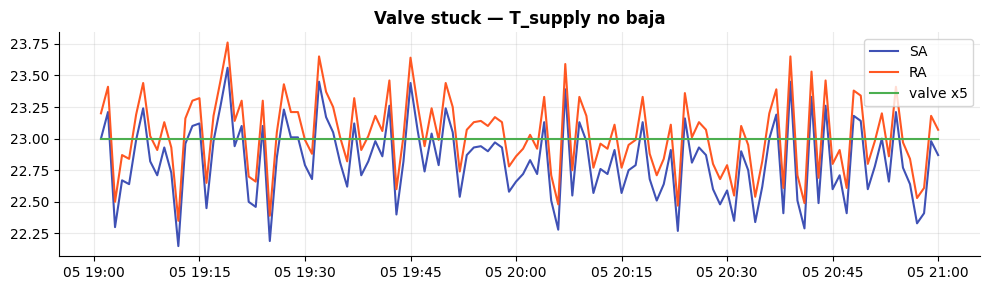

In [5]:
mask = df["fault_type"] == "valve_stuck"
if mask.any():
    win = df.loc[mask].head(120)
    plt.figure(figsize=(10, 3))
    plt.plot(win["timestamp"], win["SA_TEMP"], label="SA", color="#3F51B5")
    plt.plot(win["timestamp"], win["RA_TEMP"], label="RA", color="#FF5722")
    plt.plot(win["timestamp"], win["CCV"] * 5 + 18, label="valve x5", color="#4CAF50")
    plt.legend()
    plt.title("Valve stuck — T_supply no baja")
    plt.tight_layout()


## 14. Validaciones

Las etiquetas deben sumar al menos 5% del dataset (mocked).


In [6]:
ratio = (df["is_fault"] == 1).mean()
print("Fault ratio:", ratio)
assert 0.05 <= ratio <= 0.6


Fault ratio: 0.10863095238095238


## 15. Errores comunes

1. Asumir que el dataset solo tiene fallo→entonces el modelo no aprende lo normal.
2. Concatenar fallos sin solapamiento (el mock incluye solapamientos).
3. Mezclar `is_fault` y `fault_type` en el mismo modelo sin preprocesar.


## 16. Ejercicios propuestos

1. Cuenta cuántos episodios de cada tipo (no puntos).
2. Visualiza ΔT durante refrigerant_low.
3. Estima la duración media por tipo de fallo.


## 17. Cómo se reutiliza con datos reales

LBNL FDD real tiene mismo schema. Para CENTINELA+ los fallos vienen de tickets manuales — convertir a `captia_fault_labels`.


## 18. Resumen final y próximos pasos

Recuerda los conceptos principales del notebook y enlaza al siguiente paso.

- Siguiente notebook: `03_case_C_hvac_anomaly_detection/02_bronze_to_silver_hvac.ipynb`.
- Documento web del caso: `docs/use-cases/case-c-hvac-anomaly.md`.


## 19. Marco teórico (nivel doctoral)

### Isolation Forest (Liu et al. 2008)

Score basado en la profundidad media $E[h(x)]$ del path al aislar $x$ en
árboles binarios construidos por particiones aleatorias:

$$
s(x, n) = 2^{-\frac{E[h(x)]}{c(n)}}
$$

con $c(n) = 2 H(n-1) - 2(n-1)/n$ y $H(i)$ harmonic number. Anomalía si
$s(x) \to 1$, normal si $s(x) \to 0.5$.

### Autoencoder (Hinton & Salakhutdinov 2006)

$$
\hat{x} = D(E(x)), \quad E: \mathbb{R}^d \to \mathbb{R}^k, \quad D: \mathbb{R}^k \to \mathbb{R}^d, \quad k \ll d
$$

con $k = 8$ neuronas en bottleneck para $d = 24$ features. Score:

$$
e(x) = \| x - \hat{x} \|_2^2, \quad \theta = \mu_e + 3\sigma_e
$$

### Catálogo de fallos (ADR-010)

| Tipo | Variable afectada | Signature |
|---|---|---|
| `sensor_drift` | `temperature_01` | drift lineal $+0.5$ °C/h |
| `valve_stuck` | `valve_state`, $T_{int}$ | $\Delta T \to 0$ tras setpoint change |
| `fan_failure` | `fan_speed_01_state`, $T_{supply}$ | $\dot V \to 0$, $T_{supply} \to T_{coil}$ |
| `refrigerant_low` | $T_{supply} - T_{return}$ | $\Delta T_{cool}$ cae 50 % |

### Métricas

$$
\text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}, \quad
\text{TPR}@1\%\text{FPR} = \text{Recall} \mid \text{FPR} \leq 0.01
$$

Objetivos: $\text{F1} \geq 0.85$, $\text{TPR}@1\%\text{FPR} \geq 0.7$.


## 20. Visión corporativa CAPTIA

### Propuesta de valor

Detectar fallos HVAC antes de que se manifiesten en quejas de alumnos o averías catastróficas tiene **doble valor**: ahorro operativo (mantenimiento predictivo en lugar de reactivo) y diferenciador comercial frente a competidores BMS sin IA.

### ROI estimado

| Concepto | Valor anual |
|---|---|
| Detección temprana avería catastrófica (~2/año × 3 500 €) | +7 000 € |
| Reducción downtime (2 h × 200 días) | +800 € |
| **Bruto** | **+7 800 €/año** |
| Coste integración | -2 000 € one-time |
| **Payback** | **~3 meses** |

### Riesgos y mitigaciones

- False positives → fatiga de alarmas. Tunear umbral con percentil 99.
- Drift en HVAC envejecido: incluir age-feature.


## 21. Bibliografía y referencias

- Liu, F. T., Ting, K. M. & Zhou, Z.-H. (2008). *Isolation Forest*. ICDM '08.
- Hinton, G. & Salakhutdinov, R. (2006). *Reducing the Dimensionality of Data with Neural Networks*. Science 313(5786).
- Granderson, J. et al. (2020). *Building Fault Detection Data to Aid Diagnostic Algorithm Creation and Performance Testing*. Scientific Data 7.
- ASHRAE (2021). *Guideline 36-2021 — High-Performance Sequences of Operation for HVAC Systems*.
